# Exploration of Bus GPS Data
This notebook explores the Parquet data collected by `bus_data_collector.py`.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style='whitegrid')

## 1. Load Data
Loading the parquet file and converting timestamps.

In [3]:
df = pd.read_parquet('data/buses_2026-05-08.parquet')

# Convert timestamp strings to datetime objects
df['timestamp_gps'] = pd.to_datetime(df['timestamp_gps'], format='ISO8601', errors='coerce')

df.head()

,patente,latitud,longitud,velocidad,servicio,direccion,operador,timestamp_gps,timestamp_captura
0,PGPT-42,-33.522568,-70.802406,0.0,T1406 00R,Regreso,38,2026-05-08 20:29:34+00:00,2026-05-08 20:31:41.340810+00:00
1,LZRD-99,-33.580883,-70.592781,5.2,T1905 00I,Ida,42,2026-05-08 20:29:43+00:00,2026-05-08 20:31:41.340810+00:00
2,THTF-21,-33.581341,-70.666382,0.0,G07,Regreso,4,2026-05-08 20:29:39+00:00,2026-05-08 20:31:41.340810+00:00
3,FLXF-99,-33.451252,-70.690010,6.7,I16,Regreso,16,2026-05-08 20:29:50+00:00,2026-05-08 20:31:41.340810+00:00
4,FLXH-91,-33.423019,-70.767441,0.0,J13,Ida,5,2026-05-08 20:29:32+00:00,2026-05-08 20:31:41.340810+00:00


## 2. Basic Information

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1377438 entries, 0 to 1377437
Data columns (total 9 columns):
 #   Column             Non-Null Count    Dtype              
---  ------             --------------    -----              
 0   patente            1377438 non-null  string             
 1   latitud            1377438 non-null  float32            
 2   longitud           1377438 non-null  float32            
 3   velocidad          1377438 non-null  float32            
 4   servicio           1377438 non-null  str                
 5   direccion          1377438 non-null  category           
 6   operador           1377438 non-null  int64              
 7   timestamp_gps      1377438 non-null  datetime64[us, UTC]
 8   timestamp_captura  1377438 non-null  datetime64[us, UTC]
dtypes: category(1), datetime64[us, UTC](2), float32(3), int64(1), str(1), string(1)
memory usage: 86.4 MB


In [5]:
df.describe()

,latitud,longitud,velocidad,operador
count,1.377438e+06,1.377438e+06,1.377438e+06,1.377438e+06
mean,-3.347334e+01,-7.064478e+01,1.164229e+01,2.694616e+01
std,4.817892e-01,1.179310e+00,1.486769e+01,1.441958e+01
min,-3.369633e+01,-7.089359e+01,0.000000e+00,0.000000e+00
25%,-3.353349e+01,-7.071039e+01,0.000000e+00,1.600000e+01
50%,-3.346750e+01,-7.065618e+01,2.400000e+00,3.400000e+01
75%,-3.342392e+01,-7.059697e+01,2.220000e+01,3.900000e+01
max,0.000000e+00,0.000000e+00,9.980000e+01,4.200000e+01


In [6]:
# Check for missing values
df.isnull().sum()

patente              0
latitud              0
longitud             0
velocidad            0
servicio             0
direccion            0
operador             0
timestamp_gps        0
timestamp_captura    0
dtype: int64

## 3. Categorical Analysis
Top routes (`servicio`) and Operators.

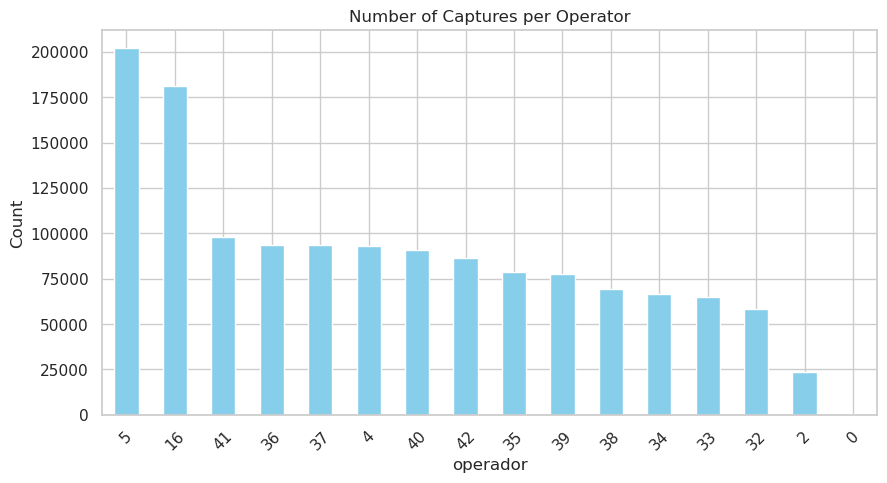

In [7]:
plt.figure(figsize=(10, 5))
df['operador'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Number of Captures per Operator')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

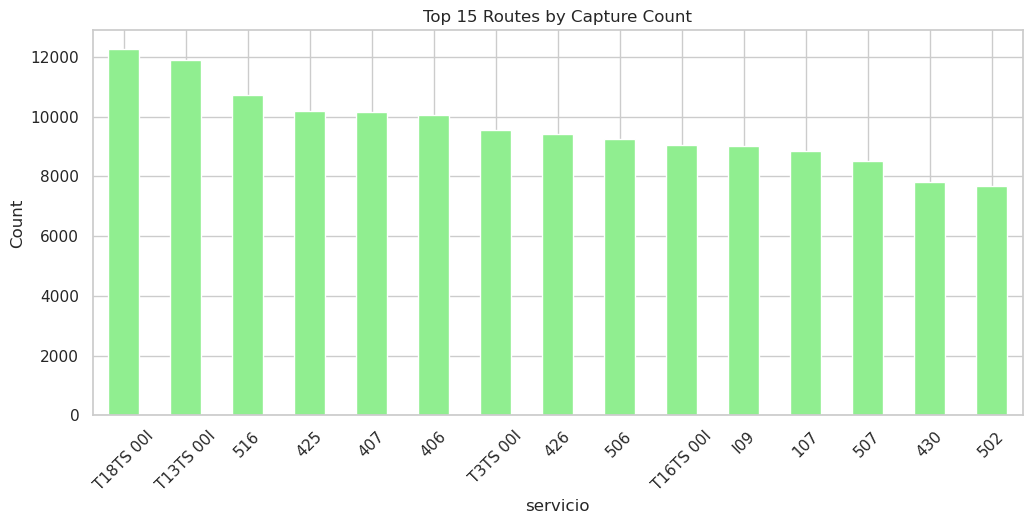

In [8]:
top_routes = df['servicio'].value_counts().head(15)
plt.figure(figsize=(12, 5))
top_routes.plot(kind='bar', color='lightgreen')
plt.title('Top 15 Routes by Capture Count')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

## 4. Speed Distribution

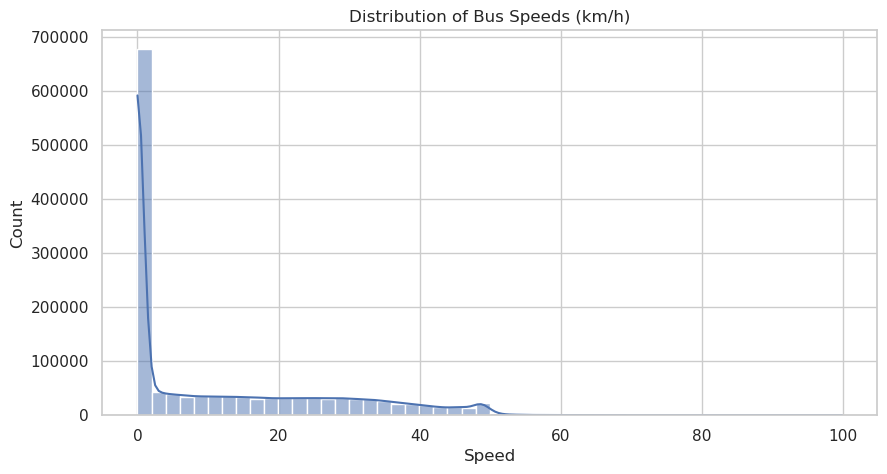

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(df['velocidad'].dropna(), bins=50, kde=True)
plt.title('Distribution of Bus Speeds (km/h)')
plt.xlabel('Speed')
plt.show()

## 5. Spatial Exploration (Scatter Plot)

In [14]:
# remove coordinates 0., 0., which are likely errors
df = df[~((df['latitud'] == 0) & (df['longitud'] == 0))]

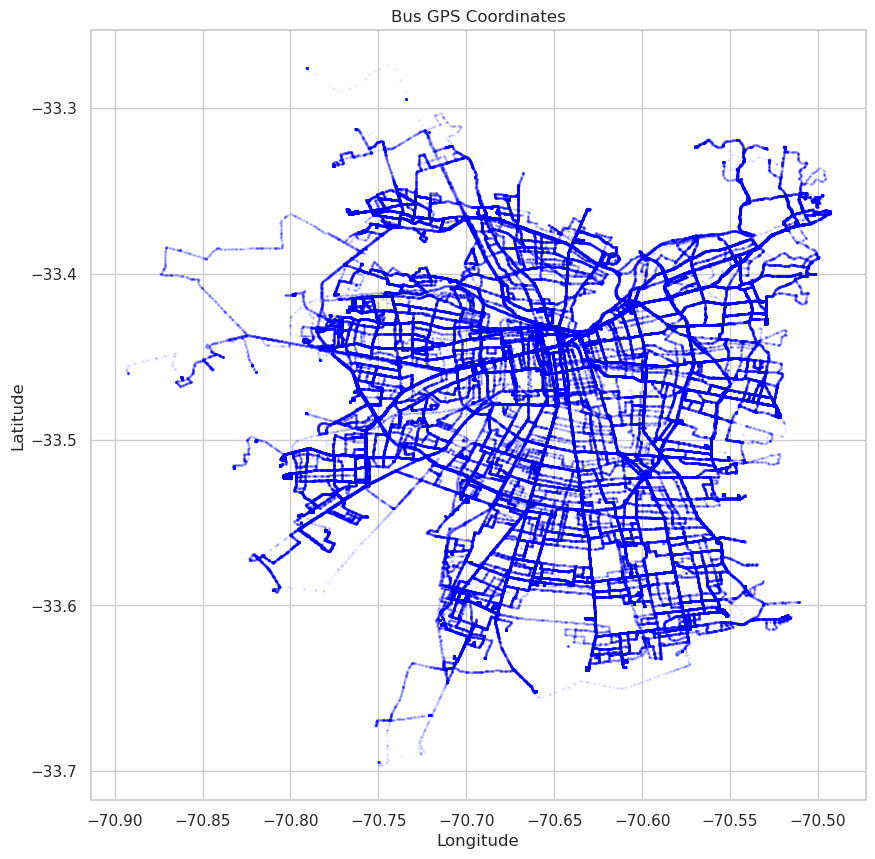

In [15]:
plt.figure(figsize=(10, 10))
# Using a small alpha to handle overplotting
plt.scatter(df['longitud'], df['latitud'], alpha=0.05, s=1, c='blue')
plt.title('Bus GPS Coordinates')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()